# **Naive Approach**

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

tf.random.set_seed(7)
np.random.seed(7)

def swiss_roll(samples=1024, noise=0.5):
    t = 1.5 * 3.14 * (1 + 2 * tf.random.uniform((samples, 1)))
    x = t * tf.math.cos(t)
    y = t * tf.math.sin(t)
    X = tf.concat([x, y], axis=1)
    if noise > 0:
        X += noise * tf.random.normal(shape=(samples, 2))
    return X


You should consider upgrading via the 'c:\Users\dorot\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


Note: you may need to restart the kernel to use updated packages.Collecting tensorflow
  Using cached tensorflow-2.21.0-cp310-cp310-win_amd64.whl (350.6 MB)
  Using cached protobuf-7.34.1-cp310-abi3-win_amd64.whl (437 kB)
  Using cached h5py-3.14.0-cp310-cp310-win_amd64.whl (2.9 MB)
  Using cached ml_dtypes-0.5.4-cp310-cp310-win_amd64.whl (210 kB)
  Using cached keras-3.12.1-py3-none-any.whl (1.5 MB)
  Using cached optree-0.19.1-cp310-cp310-win_amd64.whl (327 kB)
  Using cached namex-0.1.0-py3-none-any.whl (5.9 kB)
  Using cached rich-15.0.0-py3-none-any.whl (310 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl (10.0 kB)
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0



In [2]:
def build_naive_model():
    inputs = tf.keras.Input(shape=(2,))
    x = inputs
    for _ in range(4):
        x = tf.keras.layers.Dense(64, use_bias=False)(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.ReLU()(x)
    outputs = tf.keras.layers.Dense(2)(x)
    return tf.keras.Model(inputs, outputs)

model = build_naive_model()
model.count_params()


13570

In [3]:
batch_size = 1024
steps = 1000
optimizer = tf.keras.optimizers.Adam(1e-3)

loss_history = []

for step in range(steps):
    target = swiss_roll(batch_size, noise=0.5)
    source = tf.random.normal((batch_size, 2))
    with tf.GradientTape() as tape:
        pred = model(source, training=True)
        loss = tf.reduce_mean(tf.square(pred - target))
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    loss_history.append(float(loss))
    if (step + 1) % 200 == 0:
        print(f"step {step + 1}: loss={loss.numpy():.4f}")


step 200: loss=47.3020
step 400: loss=47.2090
step 600: loss=45.7628
step 800: loss=46.4477
step 1000: loss=47.3415


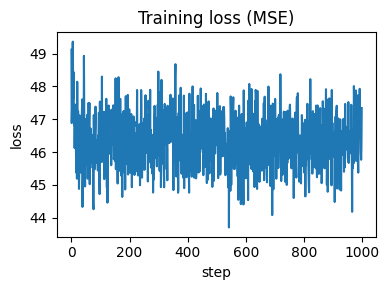

In [4]:
plt.figure(figsize=(4, 3))
plt.plot(loss_history)
plt.title("Training loss (MSE)")
plt.xlabel("step")
plt.ylabel("loss")
plt.tight_layout()


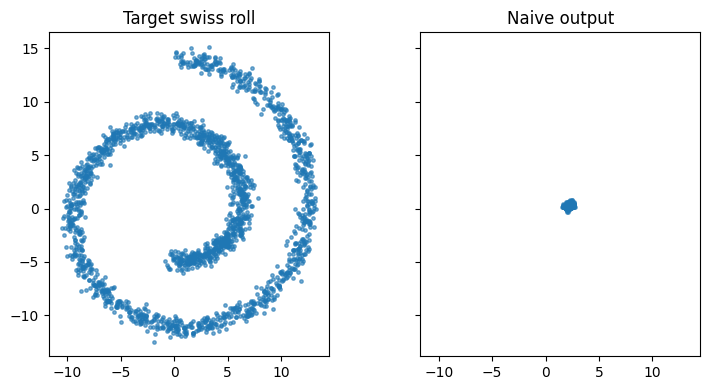

In [5]:
target = swiss_roll(2000, noise=0.5).numpy()
gen = model(tf.random.normal((2000, 2)), training=False).numpy()

fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharex=True, sharey=True)
axes[0].scatter(target[:, 0], target[:, 1], s=6, alpha=0.6)
axes[0].set_title("Target swiss roll")
axes[1].scatter(gen[:, 0], gen[:, 1], s=6, alpha=0.6)
axes[1].set_title("Naive output")
for ax in axes:
    ax.set_aspect("equal")
plt.tight_layout()


# **Variational Autoencoders**

In [6]:
latent_dim = 2

encoder_inputs = tf.keras.Input(shape=(2,))
x = tf.keras.layers.Dense(64, activation="relu")(encoder_inputs)
x = tf.keras.layers.Dense(64, activation="relu")(x)
latent = tf.keras.layers.Dense(latent_dim * 2)(x)
mean = tf.keras.layers.Lambda(lambda t: t[:, :latent_dim])(latent)
logvar = tf.keras.layers.Lambda(lambda t: t[:, latent_dim:])(latent)
encoder = tf.keras.Model(encoder_inputs, [mean, logvar], name="encoder")

decoder = tf.keras.Sequential(
    [
        tf.keras.layers.InputLayer(input_shape=(latent_dim,)),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(2),
    ],
    name="decoder",
)

encoder.count_params() + decoder.count_params()


c:\Users\dorot\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


9094

In [7]:
batch_size = 1024
steps = 1000
optimizer = tf.keras.optimizers.Adam(1e-3)

vae_loss_history = []
vae_recon_history = []
vae_kl_history = []

for step in range(steps):
    x = swiss_roll(batch_size, noise=0.5)
    with tf.GradientTape() as tape:
        mean, logvar = encoder(x, training=True)
        std = tf.exp(0.5 * logvar)
        eps = tf.random.normal(tf.shape(std))
        z = mean + std * eps
        recon = decoder(z, training=True)
        recon_loss = tf.reduce_mean(tf.square(recon - x))
        kl = 0.5 * tf.reduce_mean(tf.reduce_sum(mean**2 + tf.exp(logvar) - logvar - 1, axis=1))
        loss = recon_loss + kl
    vars_all = encoder.trainable_variables + decoder.trainable_variables
    grads = tape.gradient(loss, vars_all)
    optimizer.apply_gradients(zip(grads, vars_all))
    vae_loss_history.append(float(loss))
    vae_recon_history.append(float(recon_loss))
    vae_kl_history.append(float(kl))
    if (step + 1) % 200 == 0:
        print(f"step {step + 1}: loss={loss.numpy():.4f}")


step 200: loss=5.3531
step 400: loss=4.8937
step 600: loss=4.7792
step 800: loss=4.6742
step 1000: loss=4.6933


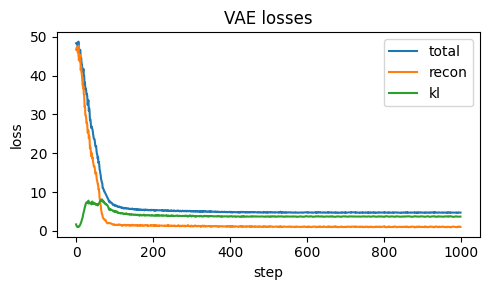

In [8]:
plt.figure(figsize=(5, 3))
plt.plot(vae_loss_history, label="total")
plt.plot(vae_recon_history, label="recon")
plt.plot(vae_kl_history, label="kl")
plt.title("VAE losses")
plt.xlabel("step")
plt.ylabel("loss")
plt.legend()
plt.tight_layout()


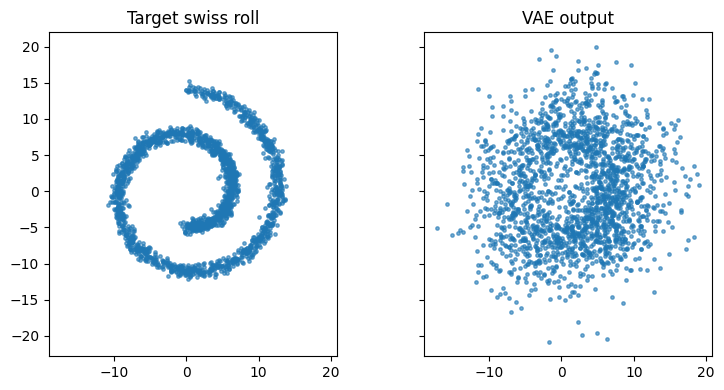

In [9]:
target = swiss_roll(2000, noise=0.5).numpy()
gen = decoder(tf.random.normal((2000, 2)), training=False).numpy()

fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharex=True, sharey=True)
axes[0].scatter(target[:, 0], target[:, 1], s=6, alpha=0.6)
axes[0].set_title("Target swiss roll")
axes[1].scatter(gen[:, 0], gen[:, 1], s=6, alpha=0.6)
axes[1].set_title("VAE output")
for ax in axes:
    ax.set_aspect("equal")
plt.tight_layout()
